# SILVA Quantum Deep Equilibrium Model

This lab reconstructs the QDEQ transition [[90]], executes a four-wire exact
statevector circuit, compares direct and implicit routes, trains a tiny task,
and lays out the ten-wire source-scale experiment.

[Download this notebook](https://github.com/jseluis/silva-networks/raw/main/notebooks/package_api/50_silva_quantum_deq.ipynb)

<!-- silva-numbered-citations:start -->
**Numbered literature:** [[1]](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [[4]](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [[81]](https://jseluis.github.io/silva-networks/paper/references/#ref-81), [[90]](https://jseluis.github.io/silva-networks/paper/references/#ref-90), [[91]](https://jseluis.github.io/silva-networks/paper/references/#ref-91), [[92]](https://jseluis.github.io/silva-networks/paper/references/#ref-92). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import sys

root = Path.cwd()
while root != root.parent and not (root / "src" / "silva_networks").exists():
    root = root.parent
if not (root / "src" / "silva_networks").exists():
    root = Path("/content/silva-networks")
sys.path.insert(0, str(root / "src"))

import matplotlib.pyplot as plt
import torch

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
torch.manual_seed(91)

## 1. Derive the Measured Equilibrium

### Derive the Circuit Transition

The input adapter produces $s=S_\psi(x)$. One tied transition is

$$
T_\theta(z,x)=\mathcal M\left(U_\theta\mathcal E(z+s)\right),
$$

and QDEQ solves

$$
z^\star=T_\theta(z^\star,x),\qquad \widehat y=Q_\omega(z^\star).
$$

For amplitude encoding,

$$
|\psi(v)\rangle=\sum_j\frac{v_j}{\|v\|_2}|j\rangle,
$$

and each measured feature is $m_j=\langle\psi|Z_j|\psi\rangle$.

In [2]:
from silva_networks import (
    SILVAQuantumDEQ,
    SILVAQuantumImageFilter,
    SILVAStatevectorQuantumCircuit,
    SolverConfig,
)

circuit = SILVAStatevectorQuantumCircuit(
    n_qubits=4,
    output_dim=4,
    fixed_depth=4,
    fixed_seed=1111,
)
directions = torch.randn(41, 16)
directions = directions / torch.linalg.vector_norm(directions, dim=1, keepdim=True)
measurements = circuit(directions)
print("measurement shape:", measurements.shape)
print("measurement range:", float(measurements.min()), float(measurements.max()))

measurement shape: torch.Size([41, 4])
measurement range: -0.6546708941459656 0.7916646003723145


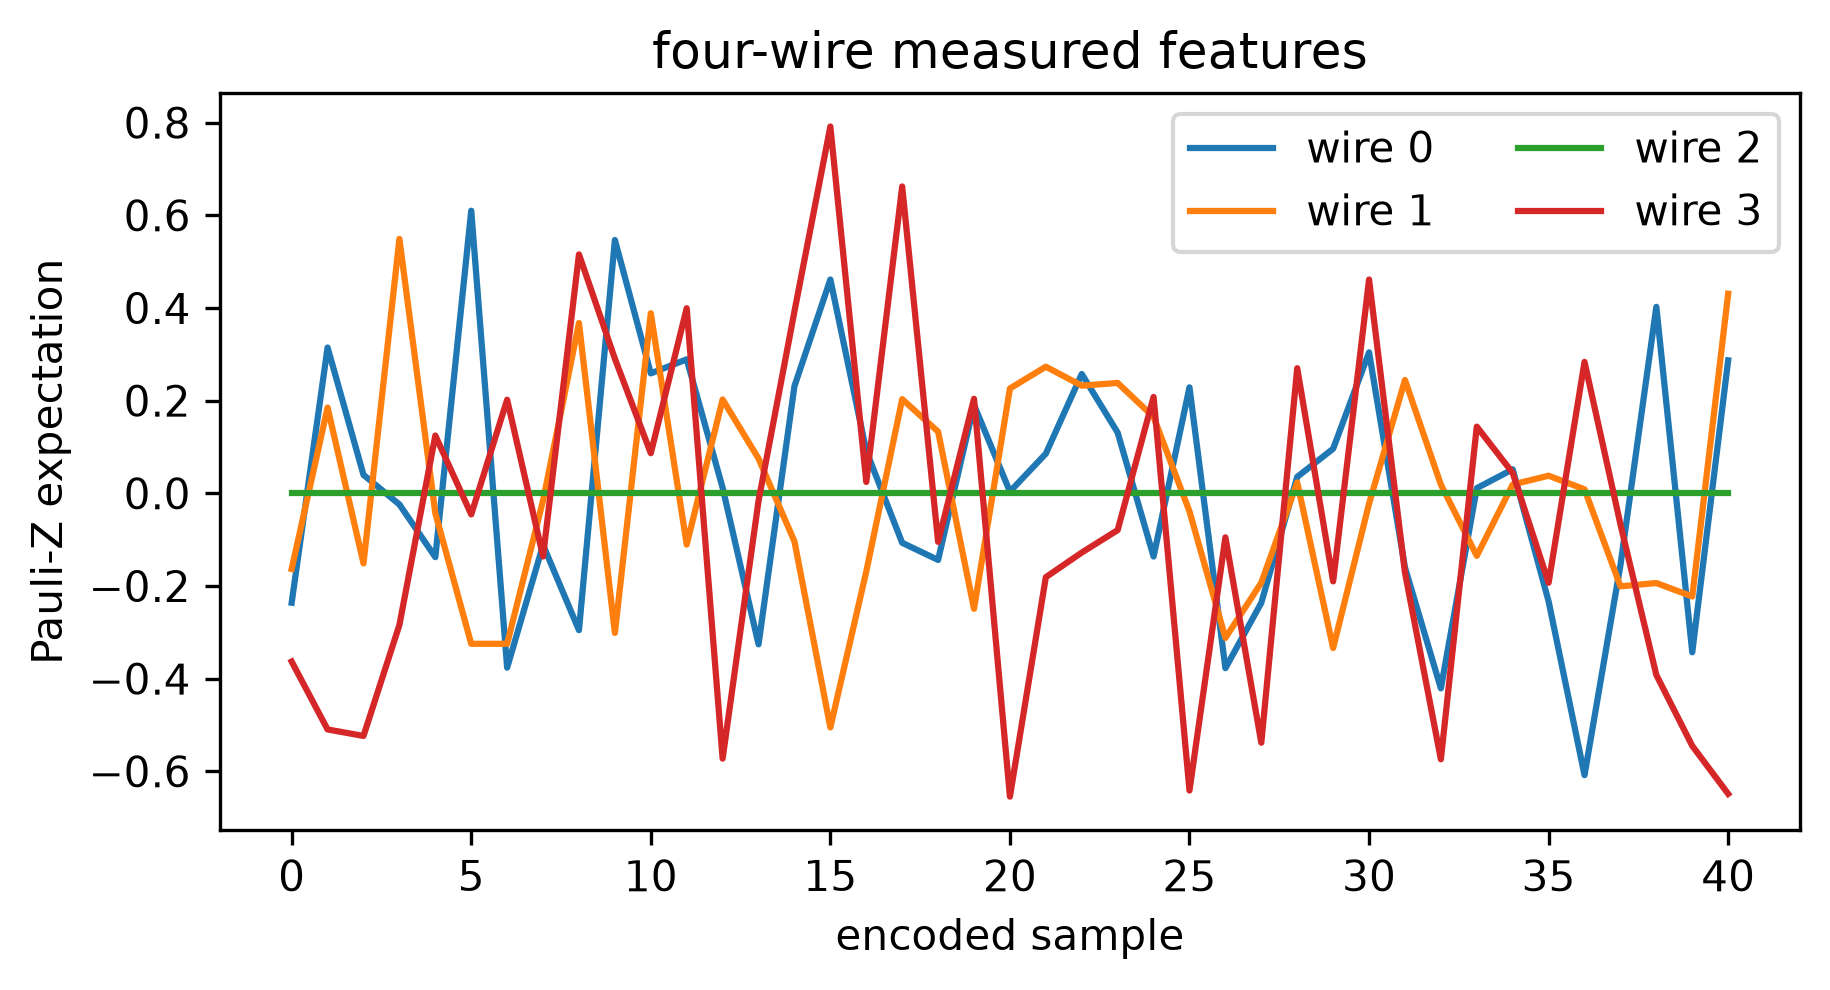

In [3]:
fig, ax = plt.subplots(figsize=(6.2, 3.4))
for wire in range(4):
    ax.plot(measurements[:, wire].detach(), label=f"wire {wire}")
ax.set(xlabel="encoded sample", ylabel="Pauli-Z expectation", title="four-wire measured features")
ax.legend(ncol=2)
fig.tight_layout()
plt.show()

## 2. Direct Warmup and Implicit Solving

Direct mode applies $z_{k+1}=T_\theta(z_k,x)$ for a finite tied depth.
Implicit mode finds a root of $T_\theta(z,x)-z$. A warmup boundary selects
the finite path before switching to the root solver.

In [4]:
model = SILVAQuantumDEQ(
    input_dim=6,
    output_dim=3,
    n_qubits=4,
    circuit=SILVAStatevectorQuantumCircuit(n_qubits=4, fixed_depth=2),
    direct_steps=3,
    warmup_steps=2,
    config=SolverConfig(
        solver="broyden",
        max_iter=7,
        tol=1e-4,
        history=5,
        backward_mode="jfb",
    ),
)
inputs = torch.randn(3, 6)
warmup = model(inputs, training_step=0, return_result=True)
implicit = model(inputs, training_step=3, compute_jacobian=True, return_result=True)
print("warmup:", warmup.state.shape, warmup.solver_result.solver, warmup.solver_result.residual)
print("implicit:", implicit.state.shape, implicit.solver_result.solver, implicit.solver_result.residual)
print("Jacobian penalty:", float(implicit.jacobian_penalty.detach()))

warmup: torch.Size([3, 16]) direct 1.096107840538025
implicit: torch.Size([3, 16]) broyden 0.160344660282135
Jacobian penalty: 18.16034698486328


## 3. Tiny Classification Study

The compact task checks the complete path: injected features, repeated circuit,
measurement, readout, loss, and parameter gradients. It is a mechanism check,
not a claim about the article's dataset accuracy.

In [5]:
torch.manual_seed(7)
train_x = torch.randn(24, 6)
train_y = (train_x[:, :3].sum(dim=1) > train_x[:, 3:].sum(dim=1)).long()
tiny = SILVAQuantumDEQ(
    input_dim=6,
    output_dim=2,
    n_qubits=4,
    circuit=SILVAStatevectorQuantumCircuit(n_qubits=4, fixed_depth=1),
    mode="direct",
    direct_steps=2,
)
optimizer = torch.optim.Adam(tiny.parameters(), lr=2e-2)
losses = []
for step in range(18):
    optimizer.zero_grad()
    logits = tiny(train_x)
    loss = torch.nn.functional.cross_entropy(logits, train_y)
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach()))
accuracy = float((tiny(train_x).argmax(dim=1) == train_y).float().mean())
print("initial loss:", losses[0])
print("final loss:", losses[-1])
print("training accuracy:", accuracy)

initial loss: 0.735220730304718
final loss: 0.11984407156705856
training accuracy: 0.9583333134651184


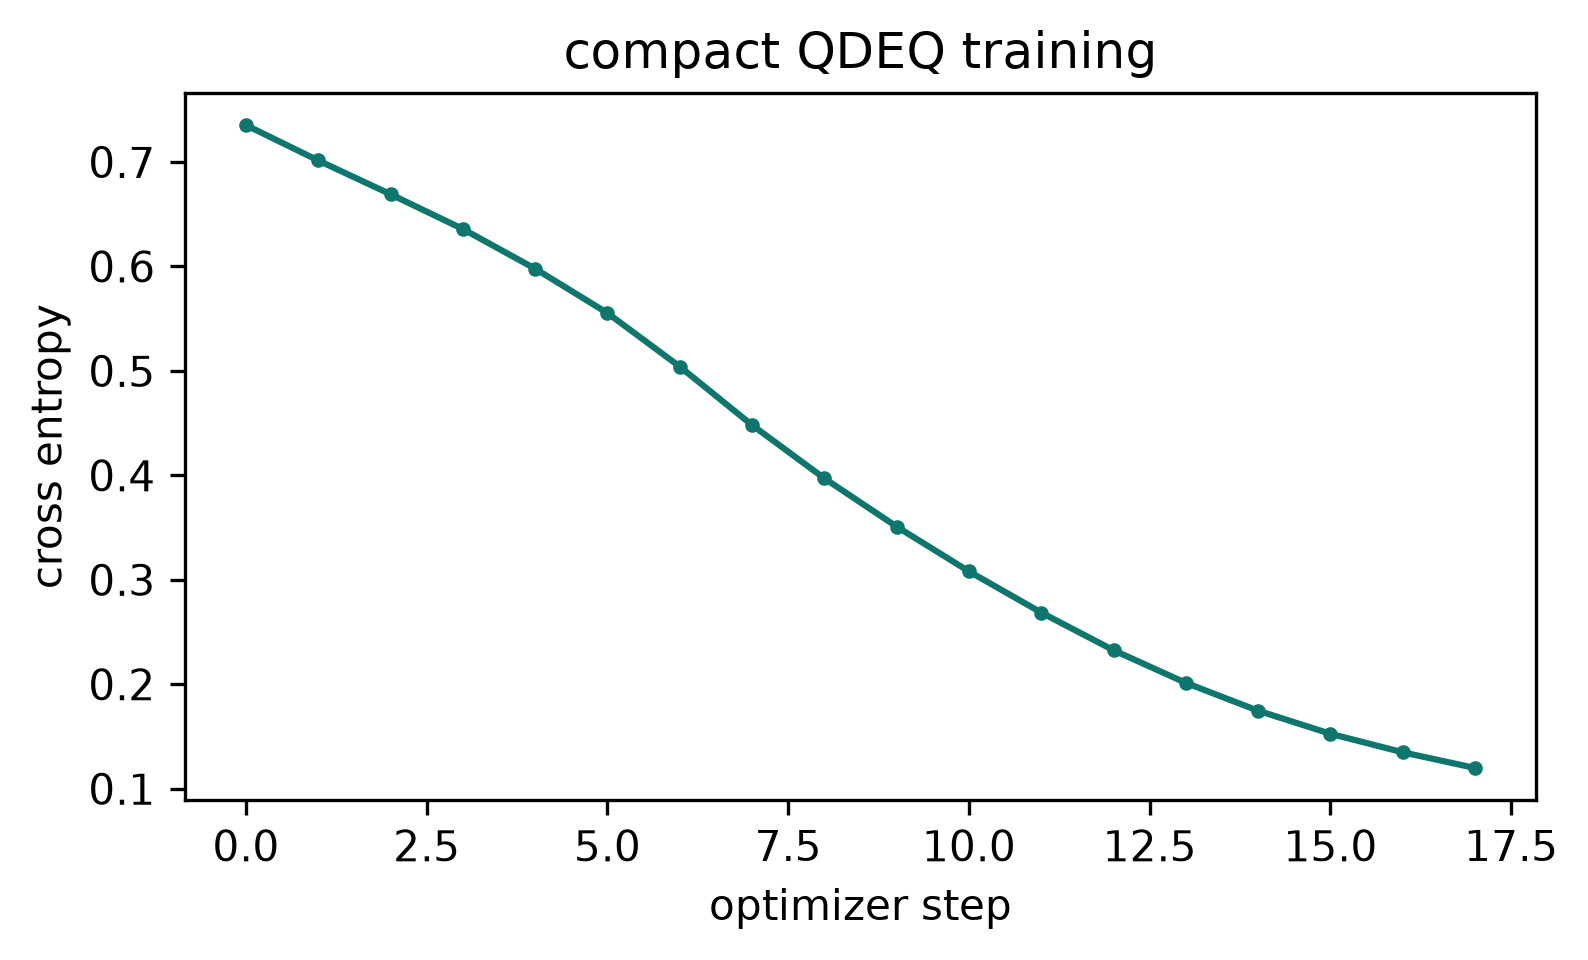

In [6]:
fig, ax = plt.subplots(figsize=(5.4, 3.3))
ax.plot(losses, color="#0f766e", marker="o", markersize=2.5)
ax.set(xlabel="optimizer step", ylabel="cross entropy", title="compact QDEQ training")
fig.tight_layout()
plt.show()

## 4. Source Image Contract

The four-wire path maps grayscale $28\times28$ images to 16 features. The
ten-wire path maps them to 100 features. The source study uses MNIST-4, MNIST,
Fashion-MNIST, and CIFAR-10 [[91]] [[92]] [[81]].

In [7]:
images = torch.randn(5, 1, 28, 28)
four_wire = SILVAQuantumImageFilter(4)(images)
ten_wire = SILVAQuantumImageFilter(10)(images)
print("four-wire image features:", four_wire.shape)
print("ten-wire image features:", ten_wire.shape)
print("four-wire statevector amplitudes:", 2**4)
print("ten-wire statevector amplitudes:", 2**10)

four-wire image features: torch.Size([5, 16])
ten-wire image features: torch.Size([5, 100])
four-wire statevector amplitudes: 16
ten-wire statevector amplitudes: 1024


## 5. Source-Scale Route

For article-scale runs, match the official split, class subset, image
preprocessing, wire count, encoding, fixed circuit seed, trainable gate pattern,
direct/warmup/implicit schedule, forward and backward thresholds, Jacobian
weight/frequency, optimizer, update count, and evaluation metric. Use
`SILVAQuantumCircuitAdapter` to place the source circuit backend behind the same
measured-state contract.

In [8]:
from silva_networks import silva_reproduction_spec

spec = silva_reproduction_spec("silva_quantum_deq")
print("equation:", spec.equation)
print("datasets:", spec.datasets)
print("repositories:", spec.repositories)
print("metrics:", spec.metrics)
print("source-scale steps:")
for index, item in enumerate(spec.source_scale_steps, 1):
    print(index, item)

equation: z_star=Measure(U_theta(Encode(z_star+S(x)))); y_hat=Q(z_star)
datasets: ('MNIST-4', 'MNIST', 'Fashion-MNIST', 'CIFAR-10', 'compact exact-statevector classification')
repositories: ('https://github.com/martaskrt/qdeq',)
metrics: ('classification accuracy', 'fixed-point residual and iterations', 'circuit evaluations', 'Jacobian penalty and gradient variance', 'wall time, memory, and shot count')
source-scale steps:
1 Acquire one declared image benchmark, preserve its official split, and reproduce the source image filter, class subset, encoding, wire count, and circuit seed.
2 Match the fixed and trainable gate sequences, measurement/interpolation rule, direct warmup, implicit-solver budget, backward rule, and Jacobian regularization schedule.
3 Report task accuracy, residual, iterations, circuit evaluations, gradient variance, wall time, memory, and shots or exact-statevector setting against direct and classical baselines.


## From 50 Silva Quantum Deq to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the measured circuit feature vector z |
| Condition | encoded classical features and optional circuit condition |
| Repeated computation | a feature-injected quantum circuit followed by real-valued measurements |
| Required invariants | wire count, encoding width, measurement shape, normalization, and differentiability |
| Replaceable components | image filter, input adapter, circuit backend, measurement map, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [9]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


custom transition: SILVATransitionReport(state_shape=(4, 3), output_shape=(4, 3), preserves_shape=True, preserves_device=True, preserves_dtype=True, finite=True, differentiable=True, parameter_count=54)
equilibrium residual: 5.960464477539063e-08


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**task error, fixed-point residual, circuit evaluations, and gradient variance**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **wire count, statevector or shot budget, circuit depth, and solver evaluations**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [10]:
notebook_reproduction_record = {
    "notebook": '50_silva_quantum_deq.ipynb',
    "state": 'the measured circuit feature vector z',
    "condition": 'encoded classical features and optional circuit condition',
    "transition": 'a feature-injected quantum circuit followed by real-valued measurements',
    "invariants": 'wire count, encoding width, measurement shape, normalization, and differentiability',
    "compact_metric": 'task error, fixed-point residual, circuit evaluations, and gradient variance',
    "scale_axis": 'wire count, statevector or shot budget, circuit depth, and solver evaluations',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


{'notebook': '50_silva_quantum_deq.ipynb',
 'state': 'the measured circuit feature vector z',
 'condition': 'encoded classical features and optional circuit condition',
 'transition': 'a feature-injected quantum circuit followed by real-valued measurements',
 'invariants': 'wire count, encoding width, measurement shape, normalization, and differentiability',
 'compact_metric': 'task error, fixed-point residual, circuit evaluations, and gradient variance',
 'scale_axis': 'wire count, statevector or shot budget, circuit depth, and solver evaluations'}

## Worked Convergence and Sensitivity Study

The preceding example demonstrates one configured solve. This additional study
changes the **transition feedback factor** while keeping the source fixed, so solver effort and
implicit sensitivity can be read separately from task behavior. Locally, one
eigendirection of a nonlinear transition can be represented by

$$
z_{k+1} = \rho z_k + u,
\qquad 0 \leq \rho < 1.
$$

Its equilibrium is

$$
z^\star = \frac{u}{1-\rho}.
$$

Subtracting the fixed-point equation from the iteration gives the exact error
recursion

$$
e_{k+1} = \rho e_k,
\qquad
|e_k| = \rho^k |e_0|.
$$

For a requested absolute tolerance $\tau$, the idealized iteration estimate is

$$
k \geq
\frac{\log(\tau/|e_0|)}{\log \rho}.
$$

The same factor controls sensitivity. Differentiating the equilibrium with
respect to the source gives

$$
\frac{\partial z^\star}{\partial u}
=\frac{1}{1-\rho}.
$$

Thus a transition can remain contractive while becoming expensive and highly
sensitive as $\rho$ approaches one. The table and figure below measure this
effect rather than merely stating it. They provide a reference envelope for
the notebook's actual state, **the measured circuit feature vector z**, and its repeated map,
**a feature-injected quantum circuit followed by real-valued measurements**. The scalar study does not replace the domain model;
it supplies a result whose convergence rate and derivative are known exactly,
so the same reporting code can be trusted before it is applied to the larger
transition.


In [11]:
import math as silva_deepening_math
import torch as silva_deepening_torch

silva_deepening_rates = (0.20, 0.45, 0.70, 0.85)
silva_deepening_source = 0.35
silva_deepening_tolerance = 1e-8
silva_deepening_histories = {}
silva_deepening_rows = []

for silva_deepening_rho in silva_deepening_rates:
    silva_deepening_state = silva_deepening_torch.tensor(0.0)
    silva_deepening_exact = silva_deepening_source / (1.0 - silva_deepening_rho)
    silva_deepening_history = []
    for silva_deepening_iteration in range(1, 241):
        silva_deepening_next = (
            silva_deepening_rho * silva_deepening_state + silva_deepening_source
        )
        silva_deepening_residual = abs(
            float(silva_deepening_next - silva_deepening_state)
        )
        silva_deepening_history.append(silva_deepening_residual)
        silva_deepening_state = silva_deepening_next
        if silva_deepening_residual < silva_deepening_tolerance:
            break

    silva_deepening_u = silva_deepening_torch.tensor(
        silva_deepening_source, requires_grad=True
    )
    silva_deepening_solution = silva_deepening_u / (1.0 - silva_deepening_rho)
    silva_deepening_solution.backward()
    silva_deepening_expected_sensitivity = 1.0 / (1.0 - silva_deepening_rho)
    silva_deepening_gradient_error = abs(
        float(silva_deepening_u.grad) - silva_deepening_expected_sensitivity
    )
    silva_deepening_histories[silva_deepening_rho] = silva_deepening_history
    silva_deepening_rows.append(
        (
            silva_deepening_rho,
            silva_deepening_iteration,
            silva_deepening_history[-1],
            abs(float(silva_deepening_state) - silva_deepening_exact),
            float(silva_deepening_u.grad),
            silva_deepening_gradient_error,
        )
    )

print('transition feedback factor')
print("rho | iterations | final residual | exact-state error | sensitivity | gradient error")
for silva_deepening_row in silva_deepening_rows:
    print(
        f"{silva_deepening_row[0]:.2f} | {silva_deepening_row[1]:3d} | "
        f"{silva_deepening_row[2]:.3e} | {silva_deepening_row[3]:.3e} | "
        f"{silva_deepening_row[4]:.4f} | {silva_deepening_row[5]:.3e}"
    )

assert all(row[2] < silva_deepening_tolerance for row in silva_deepening_rows)
assert all(row[3] < 1e-6 for row in silva_deepening_rows)
assert all(row[5] < 1e-6 for row in silva_deepening_rows)


transition feedback factor
rho | iterations | final residual | exact-state error | sensitivity | gradient error
0.20 |  12 | 0.000e+00 | 5.551e-17 | 1.2500 | 0.000e+00
0.45 |  23 | 0.000e+00 | 1.084e-08 | 1.8182 | 6.502e-08
0.70 |  45 | 0.000e+00 | 1.589e-07 | 3.3333 | 7.947e-08
0.85 |  93 | 0.000e+00 | 5.563e-07 | 6.6667 | 1.589e-07


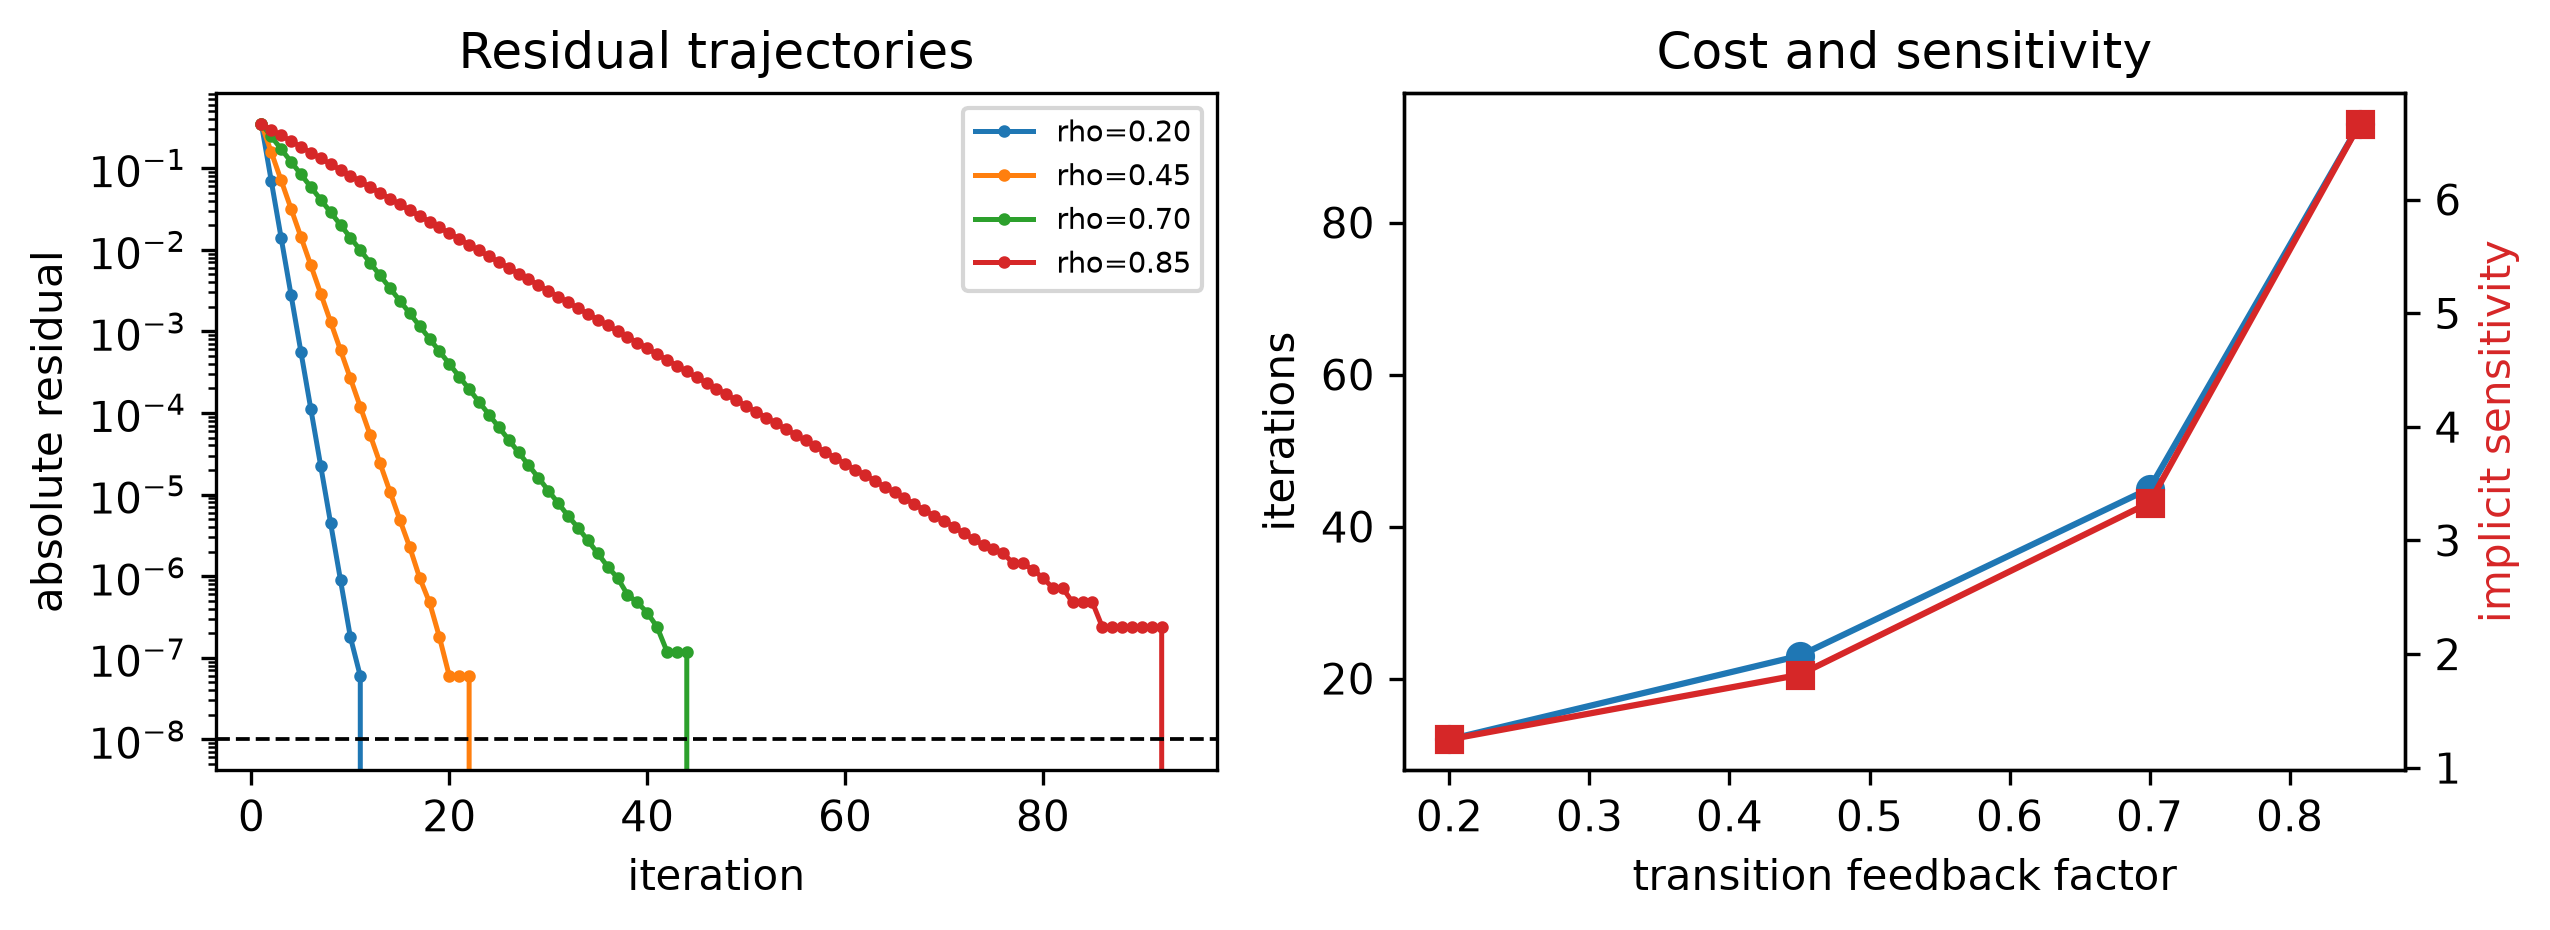

In [12]:
import matplotlib.pyplot as silva_deepening_plt

silva_deepening_plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
silva_deepening_figure, silva_deepening_axes = silva_deepening_plt.subplots(
    1, 2, figsize=(8.6, 3.2)
)
for silva_deepening_rho, silva_deepening_history in silva_deepening_histories.items():
    silva_deepening_axes[0].semilogy(
        range(1, len(silva_deepening_history) + 1),
        silva_deepening_history,
        marker="o",
        markersize=2,
        linewidth=1.2,
        label=f"rho={silva_deepening_rho:.2f}",
    )
silva_deepening_axes[0].axhline(
    silva_deepening_tolerance, color="black", linestyle="--", linewidth=0.9
)
silva_deepening_axes[0].set_xlabel("iteration")
silva_deepening_axes[0].set_ylabel("absolute residual")
silva_deepening_axes[0].set_title("Residual trajectories")
silva_deepening_axes[0].legend(fontsize=7)

silva_deepening_axes[1].plot(
    [row[0] for row in silva_deepening_rows],
    [row[1] for row in silva_deepening_rows],
    marker="o",
    label="iterations",
)
silva_deepening_sensitivity_axis = silva_deepening_axes[1].twinx()
silva_deepening_sensitivity_axis.plot(
    [row[0] for row in silva_deepening_rows],
    [row[4] for row in silva_deepening_rows],
    color="tab:red",
    marker="s",
    label="sensitivity",
)
silva_deepening_axes[1].set_xlabel('transition feedback factor')
silva_deepening_axes[1].set_ylabel("iterations")
silva_deepening_sensitivity_axis.set_ylabel("implicit sensitivity", color="tab:red")
silva_deepening_axes[1].set_title("Cost and sensitivity")
silva_deepening_figure.tight_layout()
silva_deepening_plt.show()


### Reading and Extending the Result

The measured residual curves become flatter as the transition feedback factor increases. The
iteration count and the exact sensitivity rise together, but they answer
different questions: iterations measure numerical work, while sensitivity
describes how strongly the equilibrium reacts to the source. The gradient-error
column verifies the differentiation path against the analytic derivative.

Apply the same separation to this notebook's full model:

| Report | Notebook-specific interpretation |
| --- | --- |
| Task evidence | task error, fixed-point residual, circuit evaluations, and gradient variance |
| Forward residual | Re-evaluate the complete transition at the returned state |
| Empirical rate | Compare consecutive residuals only after the transient regime |
| Backward residual | Record the linear-adjoint stopping value independently |
| Sensitivity | Perturb one declared source field while preserving all other inputs |
| Structural checks | wire count, encoding width, measurement shape, normalization, and differentiability |
| Scale sweep | Change one of wire count, statevector or shot budget, circuit depth, and solver evaluations at a time |

A richer experiment should now repeat the sweep with at least two forward
solvers, two tolerances, and multiple seeds. Keep model parameters and data
identical when comparing solvers. Then change one architecture or data-scale
axis, retain the compact analytic study as a regression test, and report task
quality, residuals, iterations, runtime, memory, gradient norms, and failed
convergence cases together.


## Where to Go Next

| Question | Page |
| --- | --- |
| How is the circuit equilibrium derived? | [Quantum Equilibria](https://jseluis.github.io/silva-networks/learn/quantum-equilibria/) |
| Where is the complete executable script? | [Quantum DEQ Example](https://jseluis.github.io/silva-networks/examples/quantum-deq/) |
| Which circuit and equilibrium objects are public? | [Quantum Equilibria API](https://jseluis.github.io/silva-networks/api/quantum_equilibria/) |
